In [ ]:
from google.colab import files
uploaded = files.upload()  # select student_performance_dataset.csv

Saving student_performance_dataset.csv to student_performance_dataset.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("student_performance_dataset.csv")
print(df.shape)
df.head()

(48, 4)


,student_id,completion_rate,avg_submission_time_days,quiz_score
0,S001,34.7,7.11,30.3
1,S002,94.7,0.93,89.2
2,S003,35.9,5.58,71.5
3,S004,93.2,1.39,87.3
4,S005,72.6,4.36,63.2


In [ ]:
df.describe()

,completion_rate,avg_submission_time_days,quiz_score
count,48.000000,48.000000,48.000000
mean,66.072917,3.364792,65.485417
std,23.730838,2.506611,18.720588
min,23.400000,0.380000,28.000000
25%,40.900000,1.195000,50.350000
50%,70.500000,2.870000,65.700000
75%,89.700000,5.310000,80.950000
max,99.900000,10.190000,99.100000


In [ ]:
from sklearn.preprocessing import StandardScaler

features = ["completion_rate", "avg_submission_time_days", "quiz_score"]
X = df[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Before scaling (first row):", X[0])
print("After scaling (first row):", X_scaled[0])

Before scaling (first row): [34.7   7.11 30.3 ]
After scaling (first row): [-1.33602172  1.50994372 -1.89939329]


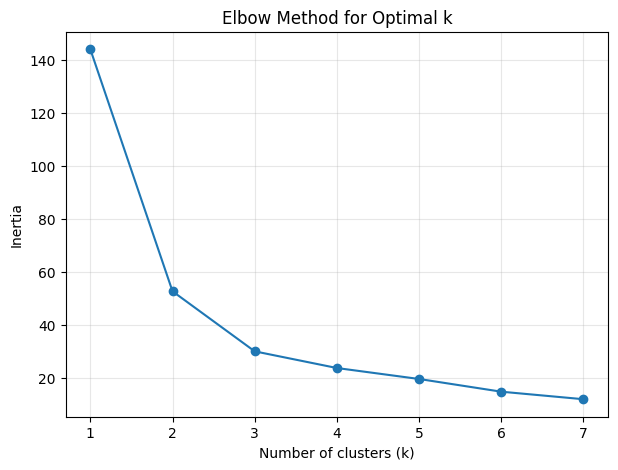

In [ ]:
from sklearn.cluster import KMeans

inertias = []
k_range = range(1, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_range)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
chosen_k = 3  # change this if your elbow plot suggests otherwise, and justify it in your writeup

kmeans = KMeans(n_clusters=chosen_k, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

df.head(10)

,student_id,completion_rate,avg_submission_time_days,quiz_score,cluster
0,S001,34.7,7.11,30.3,1
1,S002,94.7,0.93,89.2,0
2,S003,35.9,5.58,71.5,1
3,S004,93.2,1.39,87.3,0
4,S005,72.6,4.36,63.2,2
5,S006,63.3,4.54,72.3,2
6,S007,41.0,6.89,49.9,1
7,S008,68.4,1.81,36.8,2
8,S009,78.2,2.35,58.5,2
9,S010,23.8,6.59,47.9,1


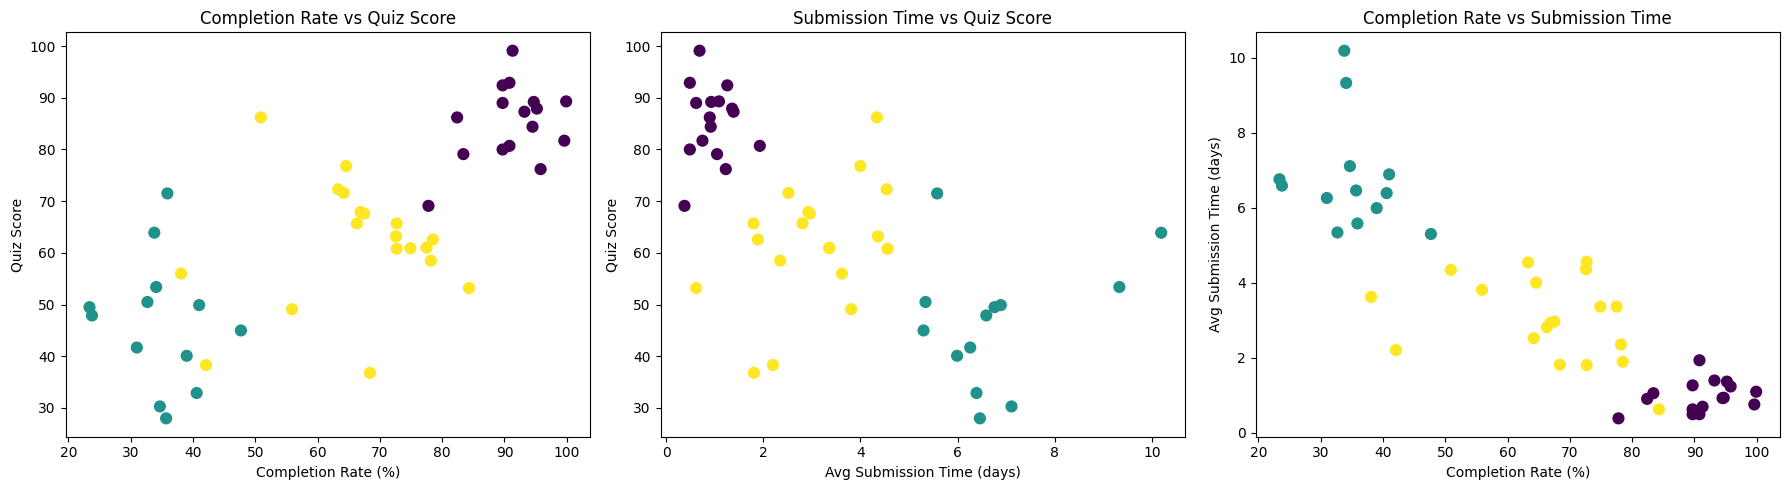

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(df["completion_rate"], df["quiz_score"], c=df["cluster"], cmap="viridis", s=60)
axes[0].set_xlabel("Completion Rate (%)")
axes[0].set_ylabel("Quiz Score")
axes[0].set_title("Completion Rate vs Quiz Score")

axes[1].scatter(df["avg_submission_time_days"], df["quiz_score"], c=df["cluster"], cmap="viridis", s=60)
axes[1].set_xlabel("Avg Submission Time (days)")
axes[1].set_ylabel("Quiz Score")
axes[1].set_title("Submission Time vs Quiz Score")

axes[2].scatter(df["completion_rate"], df["avg_submission_time_days"], c=df["cluster"], cmap="viridis", s=60)
axes[2].set_xlabel("Completion Rate (%)")
axes[2].set_ylabel("Avg Submission Time (days)")
axes[2].set_title("Completion Rate vs Submission Time")

plt.tight_layout()
plt.show()

In [ ]:
cluster_summary = df.groupby("cluster")[features].mean().round(1)
cluster_summary["num_students"] = df.groupby("cluster").size()
print(cluster_summary)

         completion_rate  avg_submission_time_days  quiz_score  num_students
cluster                                                                     
0                   91.2                       1.0        85.3            16
1                   34.9                       6.8        46.5            13
2                   66.3                       3.0        61.8            19


In [ ]:
# Example — adjust based on YOUR actual printed means above
labels = {
    0: "High performers — fast submitters, high completion, strong scores",
    1: "At-risk — low completion, slow submission, weak scores",
    2: "Average — steady but inconsistent performance"
}
df["segment_label"] = df["cluster"].map(labels)
df[["student_id", "cluster", "segment_label"]].head(10)

,student_id,cluster,segment_label
0,S001,1,"At-risk — low completion, slow submission, wea..."
1,S002,0,"High performers — fast submitters, high comple..."
2,S003,1,"At-risk — low completion, slow submission, wea..."
3,S004,0,"High performers — fast submitters, high comple..."
4,S005,2,Average — steady but inconsistent performance
5,S006,2,Average — steady but inconsistent performance
6,S007,1,"At-risk — low completion, slow submission, wea..."
7,S008,2,Average — steady but inconsistent performance
8,S009,2,Average — steady but inconsistent performance
9,S010,1,"At-risk — low completion, slow submission, wea..."


In [ ]:
mentoring_actions = {
    "High performers — fast submitters, high completion, strong scores":
        "Offer advanced/stretch material or peer-mentoring roles to keep them engaged.",
    "At-risk — low completion, slow submission, weak scores":
        "Schedule a 1-on-1 check-in and set smaller intermediate deadlines to rebuild momentum.",
    "Average — steady but inconsistent performance":
        "Send targeted reminders before deadlines and offer optional office hours for weak topics."
}
for label, action in mentoring_actions.items():
    print(f"{label}\n  -> {action}\n")

High performers — fast submitters, high completion, strong scores
  -> Offer advanced/stretch material or peer-mentoring roles to keep them engaged.

At-risk — low completion, slow submission, weak scores
  -> Schedule a 1-on-1 check-in and set smaller intermediate deadlines to rebuild momentum.

Average — steady but inconsistent performance
  -> Send targeted reminders before deadlines and offer optional office hours for weak topics.



In [ ]:
# Look for outliers/borderline students that may be dragging cluster centers
distances = kmeans.transform(X_scaled)  # distance to every cluster center
df["dist_to_own_cluster"] = [distances[i, c] for i, c in enumerate(df["cluster"])]

print("Students farthest from their assigned cluster center (potential borderline cases):")
print(df.sort_values("dist_to_own_cluster", ascending=False)[["student_id"] + features + ["cluster", "dist_to_own_cluster"]].head(6))

Students farthest from their assigned cluster center (potential borderline cases):
   student_id  completion_rate  avg_submission_time_days  quiz_score  cluster  \
27       S028             42.1                      2.20        38.3        2   
44       S045             33.8                     10.19        63.9        1   
32       S033             50.9                      4.34        86.2        2   
7        S008             68.4                      1.81        36.8        2   
2        S003             35.9                      5.58        71.5        1   
14       S015             84.3                      0.62        53.2        2   

    dist_to_own_cluster  
27             1.669356  
44             1.664153  
32             1.561299  
7              1.441162  
2              1.434453  
14             1.326152  
